In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
right_img = cv2.imread('/kaggle/input/cv-stitiching/right.jpg')
right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)
right_gray = cv2.cvtColor(right_img,cv2.COLOR_RGB2GRAY)

left_img = cv2.imread('/kaggle/input/cv-stitiching/left.jpg')
left_img = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
left_gray = cv2.cvtColor(left_img,cv2.COLOR_RGB2GRAY)

In [19]:
print(left_img.shape)

(683, 1024, 3)


In [20]:
def plot_img(img, cmap='gray'):
    plt.imshow(img, cmap)
    plt.axis('off')
    plt.show()

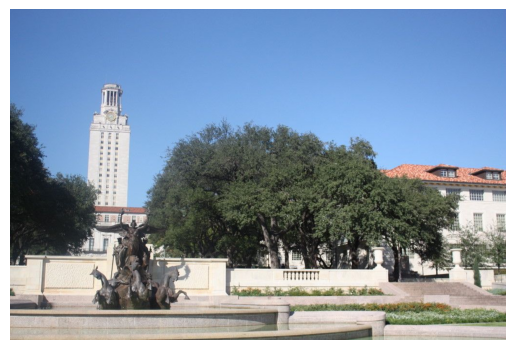

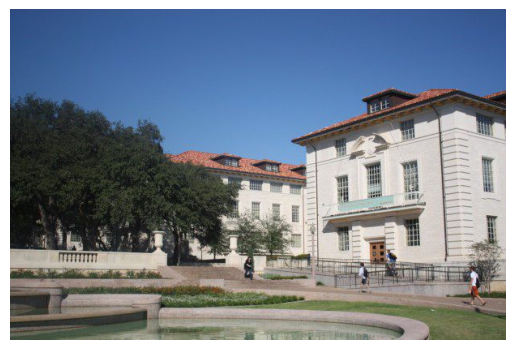

In [21]:
plot_img(left_img)
plot_img(right_img)

In [22]:
def compute_H_basic(src_pts, dst_pts):
    A = []
    for (x, y), (xp, yp) in zip(src_pts, dst_pts):
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
    A = np.array(A)

    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    return H / H[2,2]

def find_H_RANSAC_easy(src_pts, dst_pts, iterations=1000, threshold=5):
    src = src_pts.reshape(-1,2)
    dst = dst_pts.reshape(-1,2)

    best_inliers = []
    best_H = None

    for _ in range(iterations):
        idx = np.random.choice(len(src), 4, replace=False)
        H = compute_H_basic(src[idx], dst[idx])

        src_h = np.hstack([src, np.ones((len(src),1))])
        proj = (H @ src_h.T).T
        proj = proj / proj[:,2][:,None]

        errors = np.linalg.norm(proj[:,:2] - dst, axis=1)

        inliers = np.where(errors < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_H = H

    H_final = compute_H_basic(src[best_inliers], dst[best_inliers])
    return H_final, best_inliers

Landmarks in the image that the algorithm believes are distinctive enough to match between images

Examples in a real photo might be:

- Corners of objects
- Edge intersections
- Unique texture points (like a brick pattern)
- Sharp high-contrast areas (like eyes in a face)

- For every descriptor in the left image, find the 2 closest descriptors in the right image.
- After that we use H instead of H_inv in warping

Closest = smallest distance (usually Euclidean distance between those 128 numbers)

In [23]:
def find_H(left_gray, right_gray):
    sift = cv2.SIFT_create()
    kp_left, desc_left = sift.detectAndCompute(left_gray, None)
    kp_right, desc_right = sift.detectAndCompute(right_gray, None)
    print(f"  Found {len(kp_left)} keypoints in left image.")
    print(f"  Found {len(kp_right)} keypoints in right image.")

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc_left, desc_right, k=2)

    good = []
    for m in matches:
        if m[0].distance < 0.5*m[1].distance:
            good.append(m[0])
    matches = np.asarray(good)

    img_matches = cv2.drawMatches(
        left_img, kp_left,   
        right_img, kp_right, 
        good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    plot_img(img_matches)

    src_pts = np.float32([kp_left[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp_right[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # src_pts = np.float32([kp_right[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
    # dst_pts = np.float32([kp_left[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)

    # H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    H, inliers = find_H_RANSAC_easy(src_pts, dst_pts)
    print("Inliers:", len(inliers))

    return H

In [24]:
def warp_perspective(img, H, out_w, out_h):
    h, w = img.shape[:2]
    output = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    for y in range(out_h):
        for x in range(out_w):
            dest_pt = np.array([x, y, 1.0])
            src_pt = H @ dest_pt
            src_pt /= src_pt[2]

            xs, ys = src_pt[0], src_pt[1]
            if 0 <= xs < w-1 and 0 <= ys < h-1:
                x0, y0 = int(xs), int(ys)
                dx, dy = xs - x0, ys - y0
                
                top_left = img[y0, x0]
                top_right = img[y0, x0+1]
                bottom_left = img[y0+1, x0]
                bottom_right = img[y0+1, x0+1]

                top = top_left * (1 - dx) + top_right * dx
                bottom = bottom_left * (1 - dx) + bottom_right * dx
                output[y, x] = top * (1 - dy) + bottom * dy

    return output

  Found 4956 keypoints in left image.
  Found 1425 keypoints in right image.


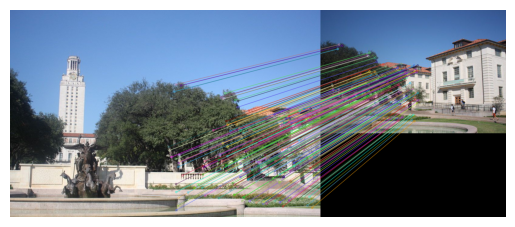

Inliers: 228


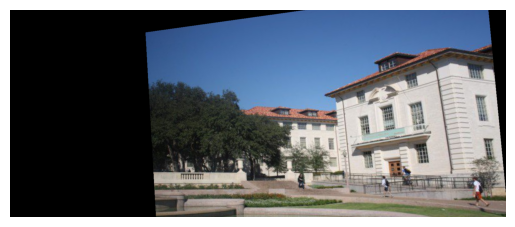

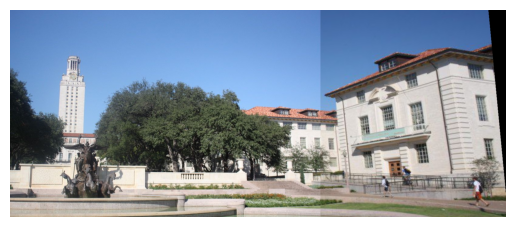

In [25]:
H = find_H(left_gray, right_gray)
output_w = left_img.shape[1] + right_img.shape[1]
output_h = left_img.shape[0]

warped = warp_perspective(right_img, H, output_w, output_h)
plot_img(warped)

warped[0:left_img.shape[0], 0:left_img.shape[1]] = left_img
plot_img(warped)

In [26]:
right_img = cv2.imread('/kaggle/input/cv-stitiching/2.jpg')
right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)
right_gray = cv2.cvtColor(right_img,cv2.COLOR_RGB2GRAY)

left_img = cv2.imread('/kaggle/input/cv-stitiching/1.jpg')
left_img = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
left_gray = cv2.cvtColor(left_img,cv2.COLOR_RGB2GRAY)

  Found 43307 keypoints in left image.
  Found 44829 keypoints in right image.


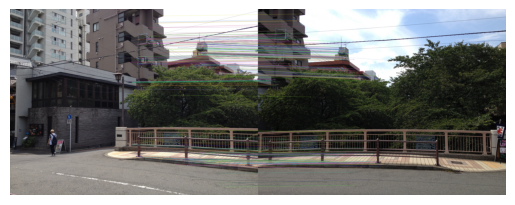

Inliers: 286


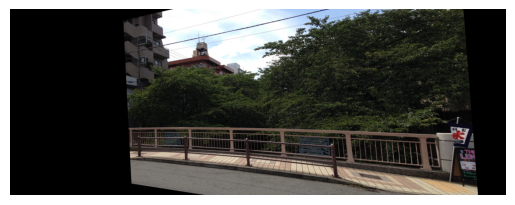

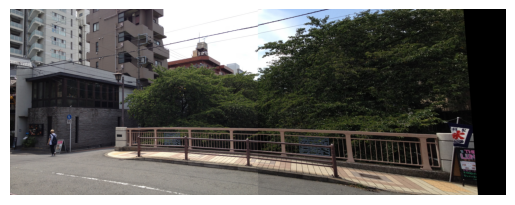

In [27]:
H = find_H(left_gray, right_gray)
output_w = left_img.shape[1] + right_img.shape[1]
output_h = left_img.shape[0]

warped_2img = warp_perspective(right_img, H, output_w, output_h)
plot_img(warped_2img)

warped_2img[0:left_img.shape[0], 0:left_img.shape[1]] = left_img
plot_img(warped_2img)

In [28]:
left_img = warped_2img
left_gray = cv2.cvtColor(left_img,cv2.COLOR_RGB2GRAY)

right_img = cv2.imread('/kaggle/input/cv-stitiching/3.jpg')
right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)
right_gray = cv2.cvtColor(right_img,cv2.COLOR_RGB2GRAY)

  Found 82954 keypoints in left image.
  Found 64155 keypoints in right image.


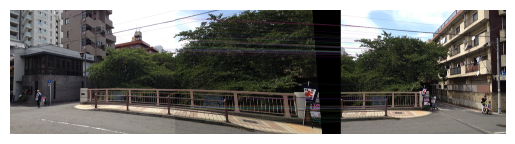

Inliers: 41


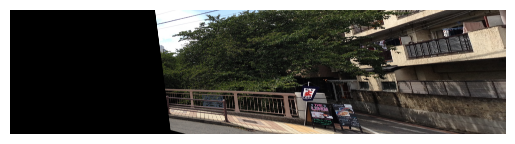

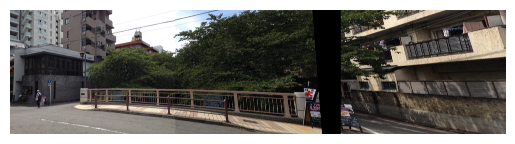

In [29]:
H = find_H(left_gray, right_gray)
output_w = left_img.shape[1] + right_img.shape[1]
output_h = left_img.shape[0]

warped_3img = warp_perspective(right_img, H, output_w, output_h)
plot_img(warped_3img)

warped_3img_ = warped_3img.copy()
warped_3img_[0:left_img.shape[0], 0:left_img.shape[1]] = left_img
plot_img(warped_3img_)

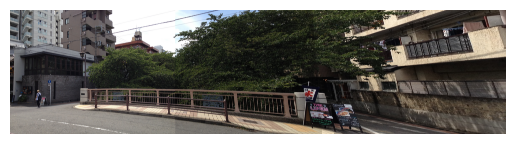

In [30]:
mask = left_img != 0
warped_3img[:left_img.shape[0], :left_img.shape[1]][mask] = left_img[mask]
plot_img(warped_3img)

In [32]:
import os

os.makedirs("/kaggle/working/results", exist_ok=True)

cv2.imwrite("/kaggle/working/results/panorama_1.png", cv2.cvtColor(warped, cv2.COLOR_RGB2BGR))
cv2.imwrite("/kaggle/working/results/panorama_2.png", cv2.cvtColor(warped_2img, cv2.COLOR_RGB2BGR))
cv2.imwrite("/kaggle/working/results/panorama_3.png", cv2.cvtColor(warped_3img, cv2.COLOR_RGB2BGR))


True